# Task 2 — Exploratory Data Analysis
**Project:** Ethiopia Financial Inclusion Forecasting System
**Analyst:** Dag Dagne | Selam Analytics
**Date:** 2026-07-19
**GitHub:** https://github.com/Dagi0808/ethiopia-fi-forecast

---
## Objective
Analyse patterns in Ethiopia's financial inclusion data, investigate the 2021–2024 stagnation puzzle,
visualise event impacts, and document at least 6 key insights with supporting evidence.


## 0. Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'ACCESS':'#1f77b4','USAGE':'#ff7f0e','GENDER':'#2ca02c',
          'AFFORDABILITY':'#d62728','event':'#9467bd','target':'#e377c2'}
FIGDIR = '../reports/figures'
os.makedirs(FIGDIR, exist_ok=True)
print("✅ Setup complete")


✅ Setup complete


## 1. Load Enriched Dataset

In [2]:
from src.data_loader import load_all
from src.enrich_data import enrich

raw = load_all()
main, impact = enrich(raw['main'].copy(), raw['impact_links'].copy())

obs     = main[main['record_type'] == 'observation'].copy()
events  = main[main['record_type'] == 'event'].copy()
targets = main[main['record_type'] == 'target'].copy()

# ensure dates are datetime
for df in [obs, events]:
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    df['year'] = df['observation_date'].dt.year

print(f"Observations : {len(obs)}")
print(f"Events       : {len(events)}")
print(f"Targets      : {len(targets)}")
print(f"Impact links : {len(impact)}")
print(f"\nPillars:\n{obs['pillar'].value_counts(dropna=False)}")


Observations : 45
Events       : 15
Targets      : 3
Impact links : 18

Pillars:
pillar
ACCESS           21
USAGE            15
GENDER            8
AFFORDABILITY     1
Name: count, dtype: int64


## 2. Dataset Overview

In [3]:
print("=== Record types ===")
print(main['record_type'].value_counts())
print("\n=== Source types (observations) ===")
print(obs['source_type'].value_counts(dropna=False))
print("\n=== Confidence levels ===")
print(obs['confidence'].value_counts(dropna=False))
print("\n=== Unique indicators ===")
ind_summary = (obs.groupby(['indicator_code','pillar'])
               .agg(records=('record_id','count'),
                    date_range=('observation_date', lambda x: f"{x.min().year}–{x.max().year}"))
               .reset_index())
print(ind_summary.to_string(index=False))


=== Record types ===
record_type
observation    45
event          15
target          3
Name: count, dtype: int64

=== Source types (observations) ===
source_type
survey        19
operator      13
research       8
regulator      3
calculated     2
Name: count, dtype: int64

=== Confidence levels ===
confidence
high      40
medium     5
Name: count, dtype: int64

=== Unique indicators ===
     indicator_code        pillar  records date_range
         ACC_4G_COV        ACCESS        2  2023–2025
    ACC_ATM_DENSITY        ACCESS        1  2022–2022
  ACC_BANK_BRANCHES        ACCESS        1  2022–2022
          ACC_FAYDA        ACCESS        3  2024–2025
     ACC_MM_ACCOUNT        ACCESS        2  2021–2024
ACC_MOBILE_INTERNET        ACCESS        1  2023–2023
     ACC_MOBILE_PEN        ACCESS        1  2025–2025
      ACC_OWNERSHIP        ACCESS        7  2011–2024
    ACC_OWNERSHIP_F        GENDER        2  2014–2017
    ACC_OWNERSHIP_M        GENDER        2  2014–2017
  ACC_OWNERSHIP_

## 3. Access Analysis — Account Ownership Trajectory 2011–2024
**Key question:** Why did growth slow to +3pp in 2021–2024 despite 65M+ mobile money accounts?

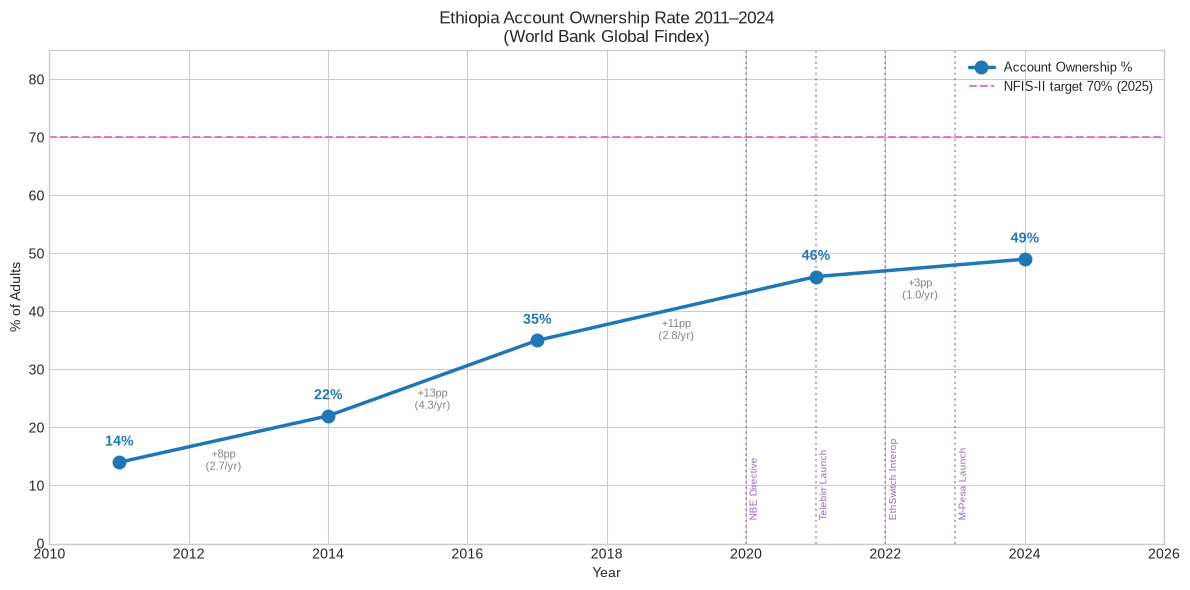

Saved fig1_access_trajectory.png


In [4]:
acc = (obs[obs['indicator_code'] == 'ACC_OWNERSHIP']
       .drop_duplicates('year').sort_values('year').query('year <= 2024'))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(acc['year'], acc['value_numeric'].astype(float), 'o-',
        color=COLORS['ACCESS'], linewidth=2.5, markersize=9, zorder=5, label='Account Ownership %')

for _, r in acc.iterrows():
    ax.annotate(f"{r['value_numeric']:.0f}%", xy=(r['year'], r['value_numeric']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=10,
                fontweight='bold', color=COLORS['ACCESS'])

years = acc['year'].tolist(); vals = acc['value_numeric'].astype(float).tolist()
for i in range(1, len(years)):
    delta = vals[i] - vals[i-1]; span = years[i] - years[i-1]
    ax.annotate(f'+{delta:.0f}pp\n({delta/span:.1f}/yr)',
                xy=((years[i]+years[i-1])/2, (vals[i]+vals[i-1])/2),
                xytext=(0, -22), textcoords='offset points', ha='center', fontsize=8, color='grey')

ax.axhline(70, color=COLORS['target'], linestyle='--', lw=1.5, label='NFIS-II target 70% (2025)')
for yr, lbl in {2020:'NBE Directive', 2021:'Telebirr Launch', 2022:'EthSwitch Interop', 2023:'M-Pesa Launch'}.items():
    ax.axvline(yr, color=COLORS['event'], linestyle=':', alpha=0.6)
    ax.text(yr+0.05, 4, lbl, fontsize=7, color=COLORS['event'], rotation=90, va='bottom')

ax.set(xlim=(2010,2026), ylim=(0,85), xlabel='Year', ylabel='% of Adults',
       title='Ethiopia Account Ownership Rate 2011–2024\n(World Bank Global Findex)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_access_trajectory.png', dpi=150)
plt.show()
print("Saved fig1_access_trajectory.png")


### Growth Rate Analysis

In [5]:
growth = []
for i in range(1, len(years)):
    growth.append({'Period': f'{years[i-1]}→{years[i]}',
                   'Change (pp)': f'+{vals[i]-vals[i-1]:.0f}',
                   'Years': years[i]-years[i-1],
                   'Rate (pp/yr)': f'{(vals[i]-vals[i-1])/(years[i]-years[i-1]):.1f}'})
pd.DataFrame(growth)


,Period,Change (pp),Years,Rate (pp/yr)
0,2011→2014,+8,3,2.7
1,2014→2017,+13,3,4.3
2,2017→2021,+11,4,2.8
3,2021→2024,+3,3,1.0


## 4. Gender Gap Analysis

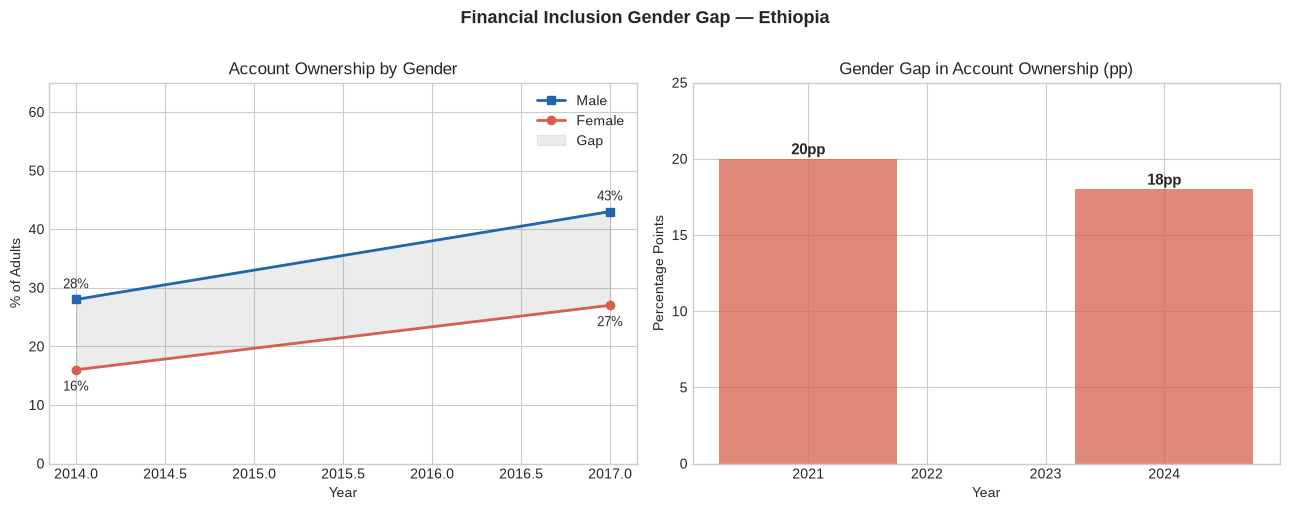

In [6]:
male   = obs[obs['indicator_code']=='ACC_OWNERSHIP_M'].drop_duplicates('year').sort_values('year')
female = obs[obs['indicator_code']=='ACC_OWNERSHIP_F'].drop_duplicates('year').sort_values('year')
gap    = obs[obs['indicator_code']=='GEN_GAP_ACC'].drop_duplicates('year').sort_values('year')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

if not male.empty and not female.empty:
    common = sorted(set(male['year']) & set(female['year']))
    m_vals = male.set_index('year').reindex(common)['value_numeric'].astype(float)
    f_vals = female.set_index('year').reindex(common)['value_numeric'].astype(float)
    ax1.plot(male['year'], male['value_numeric'].astype(float), 's-', color='#2166ac', lw=2, label='Male')
    ax1.plot(female['year'], female['value_numeric'].astype(float), 'o-', color='#d6604d', lw=2, label='Female')
    if common:
        ax1.fill_between(common, f_vals.values, m_vals.values, alpha=0.15, color='grey', label='Gap')
    for _, r in male.iterrows():
        ax1.annotate(f"{r['value_numeric']:.0f}%", (r['year'], r['value_numeric']),
                     textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
    for _, r in female.iterrows():
        ax1.annotate(f"{r['value_numeric']:.0f}%", (r['year'], r['value_numeric']),
                     textcoords='offset points', xytext=(0,-15), ha='center', fontsize=9)
    ax1.set(title='Account Ownership by Gender', ylabel='% of Adults', xlabel='Year', ylim=(0,65))
    ax1.legend()

if not gap.empty:
    bars = ax2.bar(gap['year'], gap['value_numeric'].astype(float), color='#d6604d', alpha=0.75, width=1.5)
    for b, v in zip(bars, gap['value_numeric'].astype(float)):
        ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.0f}pp',
                 ha='center', fontsize=11, fontweight='bold')
    ax2.set(title='Gender Gap in Account Ownership (pp)', ylabel='Percentage Points', xlabel='Year', ylim=(0,25))

plt.suptitle('Financial Inclusion Gender Gap — Ethiopia', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig2_gender_gap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Usage Analysis — Digital Payment Adoption & Registered vs Active Gap

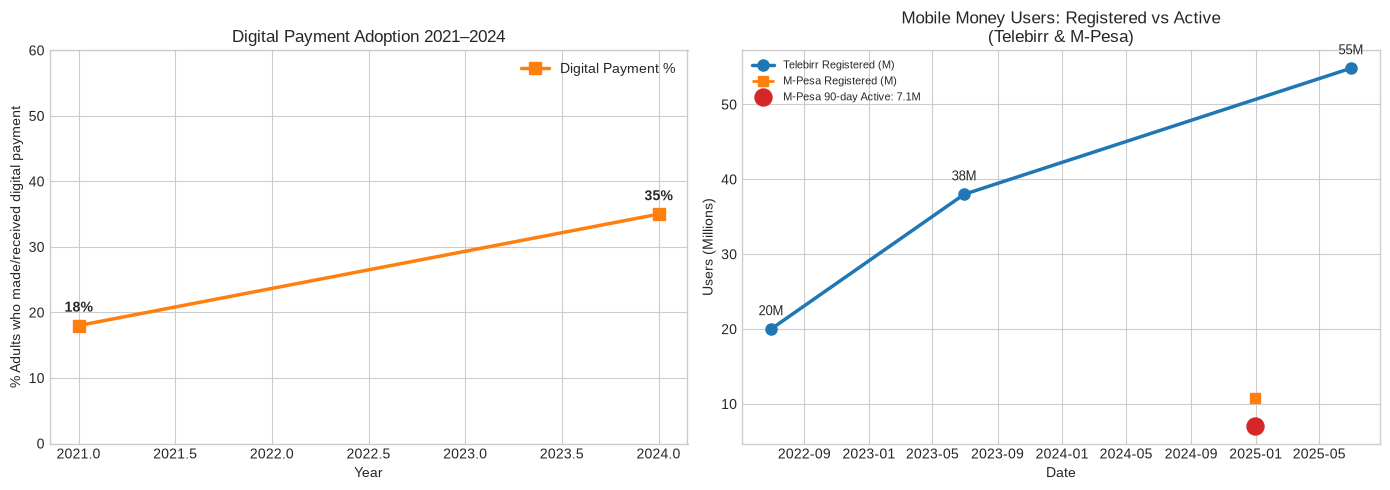


Mobile Money Activity Rate: 66%
Telebirr registered (Jun 2025): 54.8M
Estimated active users: 36.2M


In [7]:
usg = obs[obs['indicator_code']=='USG_DIGITAL_PAYMENT'].drop_duplicates('year').sort_values('year')
tb  = obs[obs['indicator_code']=='USG_TELEBIRR_USERS'].sort_values('observation_date')
mp  = obs[obs['indicator_code']=='USG_MPESA_USERS'].sort_values('observation_date')
act = obs[obs['indicator_code']=='USG_MPESA_ACTIVE']
ar  = obs[obs['indicator_code']=='USG_ACTIVE_RATE']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Digital payment trend
if not usg.empty:
    ax1.plot(usg['year'], usg['value_numeric'].astype(float), 's-',
             color=COLORS['USAGE'], lw=2.5, markersize=9, label='Digital Payment %')
    for _, r in usg.iterrows():
        ax1.annotate(f"{r['value_numeric']:.0f}%", (r['year'], r['value_numeric']),
                     textcoords='offset points', xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
ax1.set(title='Digital Payment Adoption 2021–2024', ylabel='% Adults who made/received digital payment',
        xlabel='Year', ylim=(0,60))
ax1.legend()

# Registered vs active
if not tb.empty:
    ax2.plot(tb['observation_date'], tb['value_numeric'].astype(float)/1e6,
             'o-', color='#1f77b4', lw=2.5, markersize=8, label='Telebirr Registered (M)')
    for _, r in tb.iterrows():
        ax2.annotate(f"{r['value_numeric']/1e6:.0f}M", (r['observation_date'], r['value_numeric']/1e6),
                     textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
if not mp.empty:
    ax2.plot(mp['observation_date'], mp['value_numeric'].astype(float)/1e6,
             's--', color='#ff7f0e', lw=2, markersize=7, label='M-Pesa Registered (M)')
if not act.empty:
    ax2.scatter(act['observation_date'], act['value_numeric'].astype(float)/1e6,
                s=150, color='#d62728', zorder=10, label=f"M-Pesa 90-day Active: {act['value_numeric'].iloc[0]/1e6:.1f}M")
ax2.set(title='Mobile Money Users: Registered vs Active\n(Telebirr & M-Pesa)',
        ylabel='Users (Millions)', xlabel='Date')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig3_usage_analysis.png', dpi=150)
plt.show()

# Activity rate
if not ar.empty:
    rate = ar['value_numeric'].iloc[0]
    print(f"\nMobile Money Activity Rate: {rate:.0f}%")
    print(f"Telebirr registered (Jun 2025): {tb.iloc[-1]['value_numeric']/1e6:.1f}M")
    print(f"Estimated active users: {tb.iloc[-1]['value_numeric']*rate/100/1e6:.1f}M")


## 6. Event Timeline Overlaid on Indicator Trends

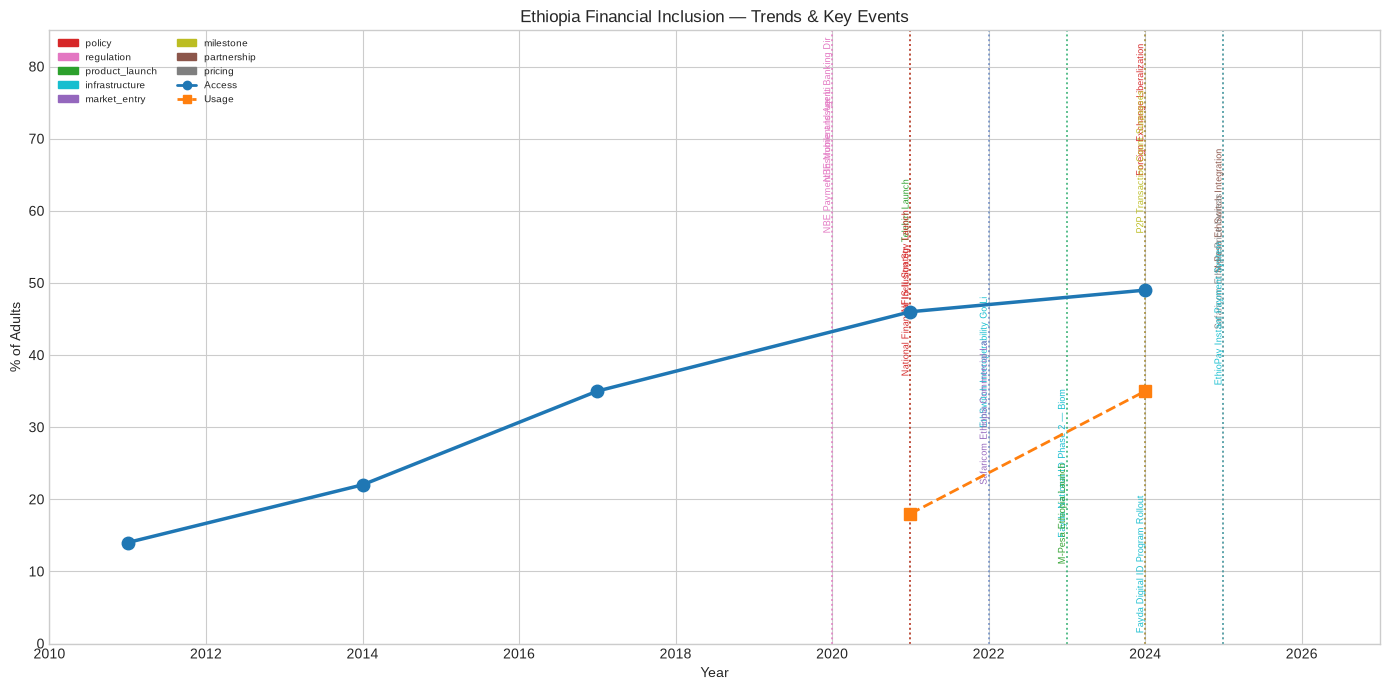

In [8]:
acc2 = obs[obs['indicator_code']=='ACC_OWNERSHIP'].drop_duplicates('year').sort_values('year').query('year<=2024')
usg2 = obs[obs['indicator_code']=='USG_DIGITAL_PAYMENT'].drop_duplicates('year').sort_values('year')

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(acc2['year'], acc2['value_numeric'].astype(float), 'o-',
        color=COLORS['ACCESS'], lw=2.5, markersize=9, label='Access (Account Ownership %)', zorder=5)
if not usg2.empty:
    ax.plot(usg2['year'], usg2['value_numeric'].astype(float), 's--',
            color=COLORS['USAGE'], lw=2, markersize=8, label='Usage (Digital Payment %)', zorder=5)

evt_colors = {'policy':'#d62728','regulation':'#e377c2','product_launch':'#2ca02c',
              'infrastructure':'#17becf','market_entry':'#9467bd','milestone':'#bcbd22',
              'partnership':'#8c564b','pricing':'#7f7f7f'}
y_pos = [74,67,60,53,46,39,32,25,18,11]
evts_sorted = events.sort_values('observation_date').reset_index(drop=True)
for i, (_, e) in enumerate(evts_sorted.iterrows()):
    yr = e['observation_date'].year
    cat = str(e.get('category','policy'))
    col = evt_colors.get(cat,'#7f7f7f')
    yp  = y_pos[i % len(y_pos)]
    ax.axvline(yr, color=col, linestyle=':', alpha=0.55, lw=1.3)
    ax.annotate(str(e['indicator'])[:32], xy=(yr, yp), fontsize=6.5,
                color=col, rotation=90, va='center', ha='right')

patches = [mpatches.Patch(color=c, label=k) for k,c in evt_colors.items()
           if k in events['category'].values]
patches += [plt.Line2D([0],[0],color=COLORS['ACCESS'],marker='o',lw=2,label='Access'),
            plt.Line2D([0],[0],color=COLORS['USAGE'],marker='s',linestyle='--',lw=2,label='Usage')]
ax.legend(handles=patches, fontsize=7, loc='upper left', ncol=2)
ax.set(xlim=(2010,2027), ylim=(0,85), xlabel='Year', ylabel='% of Adults',
       title='Ethiopia Financial Inclusion — Trends & Key Events')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig4_event_timeline.png', dpi=150)
plt.show()


## 7. P2P vs ATM Crossover — The Digital Tipping Point

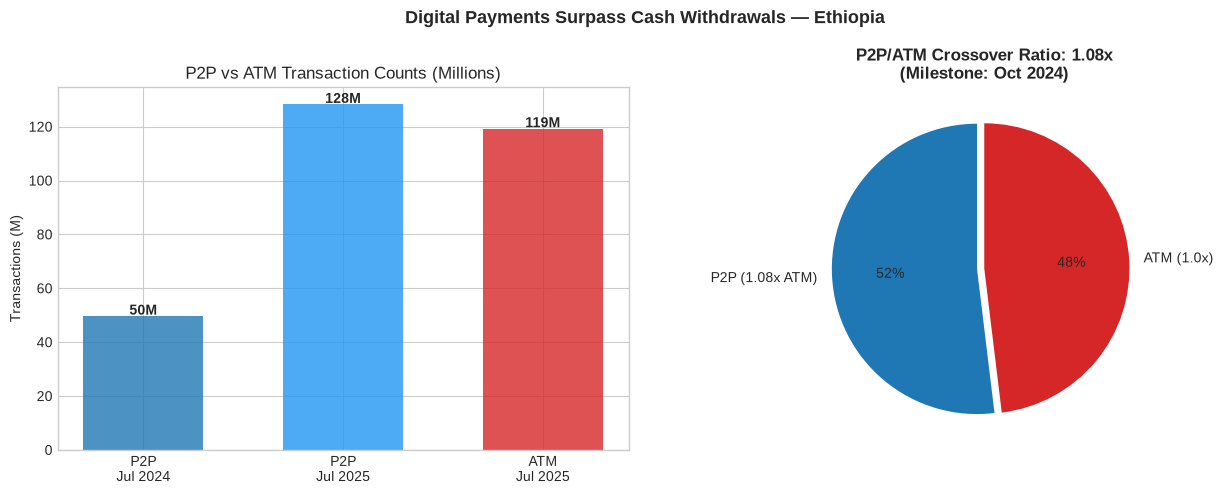

P2P transactions grew from 50M to 128M — a 3x increase


In [9]:
p2p = obs[obs['indicator_code']=='USG_P2P_COUNT'].sort_values('observation_date')
atm = obs[obs['indicator_code']=='USG_ATM_COUNT']
crs = obs[obs['indicator_code']=='USG_CROSSOVER']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

if not p2p.empty and not atm.empty:
    labels = [f"P2P\n{p2p.iloc[0]['observation_date'].strftime('%b %Y')}",
              f"P2P\n{p2p.iloc[-1]['observation_date'].strftime('%b %Y')}",
              f"ATM\n{atm.iloc[-1]['observation_date'].strftime('%b %Y')}"]
    vals_bar = [p2p.iloc[0]['value_numeric']/1e6, p2p.iloc[-1]['value_numeric']/1e6,
                atm.iloc[-1]['value_numeric']/1e6]
    colors_bar = ['#1f77b4','#2196F3','#d62728']
    bars = [ax1.bar(i, v, color=c, alpha=0.8, width=0.6)
            for i,(v,c) in enumerate(zip(vals_bar, colors_bar))]
    bars = [b[0] for b in bars]
    ax1.set_xticks([0,1,2]); ax1.set_xticklabels(labels)
    for b,v in zip(bars, vals_bar):
        ax1.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}M', ha='center', fontsize=10, fontweight='bold')
    ax1.set(title='P2P vs ATM Transaction Counts (Millions)', ylabel='Transactions (M)')

if not crs.empty:
    ratio = float(crs['value_numeric'].iloc[0])
    ax2.pie([ratio, 1], labels=[f'P2P ({ratio:.2f}x ATM)', 'ATM (1.0x)'],
            colors=['#1f77b4','#d62728'], autopct='%1.0f%%', startangle=90, explode=[0.05,0])
    ax2.set_title(f'P2P/ATM Crossover Ratio: {ratio:.2f}x\n(Milestone: Oct 2024)', fontweight='bold')

plt.suptitle('Digital Payments Surpass Cash Withdrawals — Ethiopia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig5_p2p_atm_crossover.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"P2P transactions grew from {p2p.iloc[0]['value_numeric']/1e6:.0f}M to {p2p.iloc[-1]['value_numeric']/1e6:.0f}M — a {p2p.iloc[-1]['value_numeric']/p2p.iloc[0]['value_numeric']:.0f}x increase")


## 8. Infrastructure Enablers vs Account Ownership

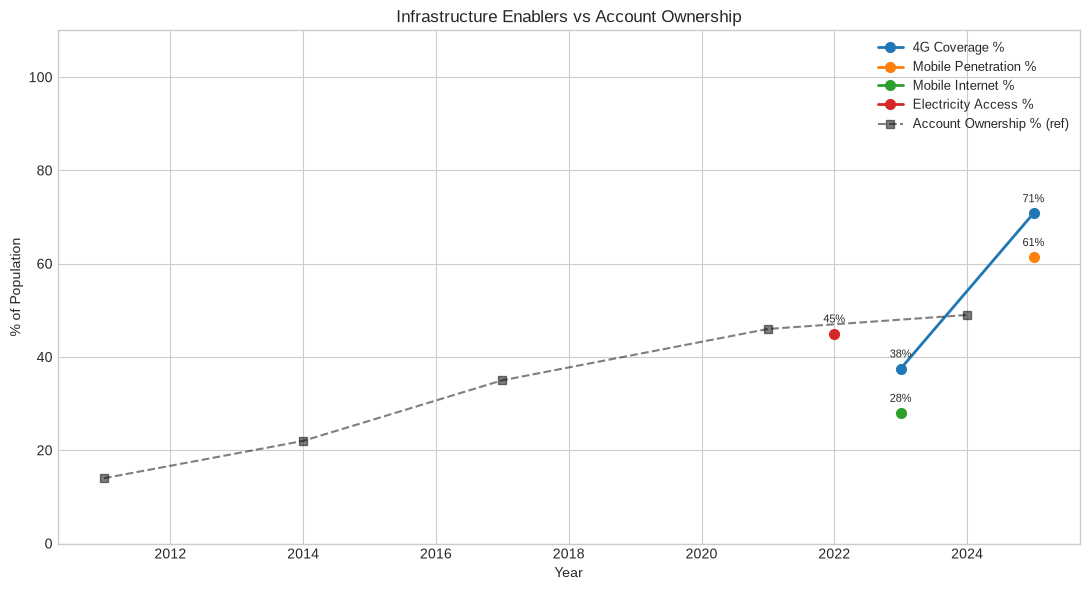

In [10]:
infra = {'ACC_4G_COV':'4G Coverage %','ACC_MOBILE_PEN':'Mobile Penetration %',
         'ACC_MOBILE_INTERNET':'Mobile Internet %','ELEC_ACCESS':'Electricity Access %'}

fig, ax = plt.subplots(figsize=(11, 6))
for code, label in infra.items():
    sub = obs[obs['indicator_code']==code].sort_values('year')
    if sub.empty: continue
    ax.plot(sub['year'], sub['value_numeric'].astype(float), 'o-', lw=2, markersize=7, label=label)
    for _, r in sub.iterrows():
        ax.annotate(f"{r['value_numeric']:.0f}%", (r['year'], r['value_numeric']),
                    textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)

acc3 = obs[obs['indicator_code']=='ACC_OWNERSHIP'].drop_duplicates('year').sort_values('year')
ax.plot(acc3['year'], acc3['value_numeric'].astype(float), 's--',
        color='black', lw=1.5, markersize=6, alpha=0.5, label='Account Ownership % (ref)')
ax.set(title='Infrastructure Enablers vs Account Ownership',
       xlabel='Year', ylabel='% of Population', ylim=(0,110))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig6_infrastructure.png', dpi=150)
plt.show()


## 9. Data Quality Assessment

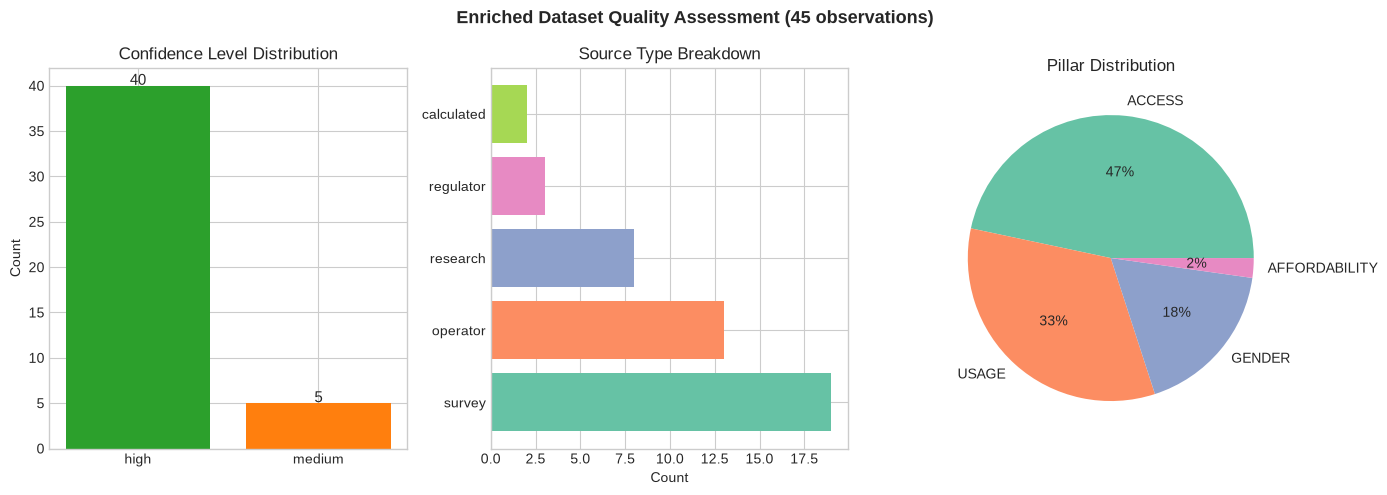

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

conf = obs['confidence'].value_counts()
axes[0].bar(conf.index, conf.values, color=['#2ca02c','#ff7f0e','#d62728','#9467bd'])
for i,(k,v) in enumerate(conf.items()): axes[0].text(i, v+0.1, str(v), ha='center', fontsize=11)
axes[0].set(title='Confidence Level Distribution', ylabel='Count')

src = obs['source_type'].value_counts()
axes[1].barh(src.index, src.values, color=sns.color_palette('Set2', len(src)))
axes[1].set(title='Source Type Breakdown', xlabel='Count')

pil = obs['pillar'].value_counts(dropna=False)
axes[2].pie(pil.values, labels=pil.index, autopct='%1.0f%%',
            colors=sns.color_palette('Set2', len(pil)))
axes[2].set_title('Pillar Distribution')

plt.suptitle('Enriched Dataset Quality Assessment (45 observations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig7_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Correlation Analysis — Which Factors Drive Access?

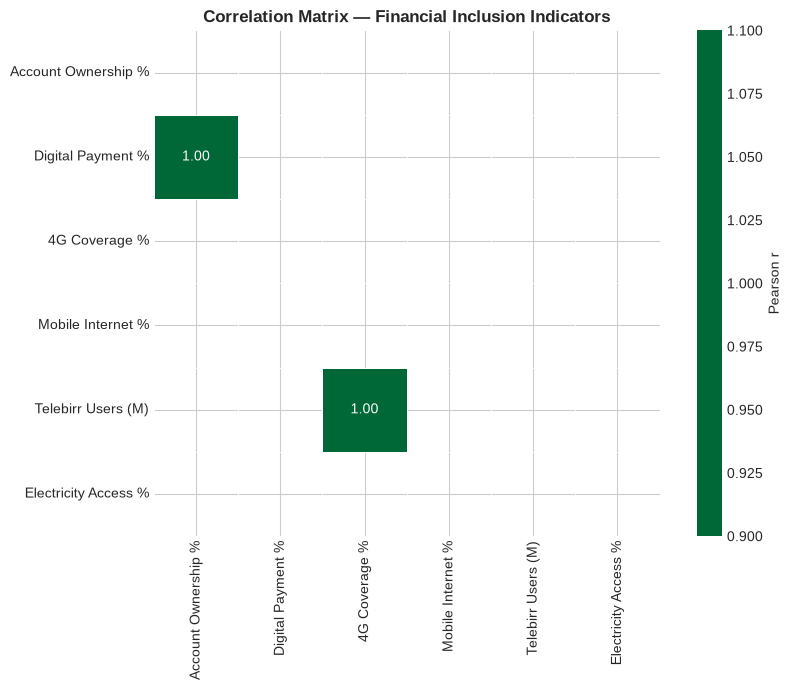

Account Ownership %     1.0
Digital Payment %       1.0
4G Coverage %           NaN
Mobile Internet %       NaN
Telebirr Users (M)      NaN
Electricity Access %    NaN


In [12]:
# Build a year-indexed dataframe of key indicators
pivot_data = {}
indicator_map = {
    'ACC_OWNERSHIP':'Account Ownership %',
    'USG_DIGITAL_PAYMENT':'Digital Payment %',
    'ACC_4G_COV':'4G Coverage %',
    'ACC_MOBILE_INTERNET':'Mobile Internet %',
    'USG_TELEBIRR_USERS':'Telebirr Users (M)',
    'ELEC_ACCESS':'Electricity Access %',
}
for code, label in indicator_map.items():
    sub = obs[obs['indicator_code']==code].drop_duplicates('year').set_index('year')['value_numeric']
    pivot_data[label] = sub.astype(float)

corr_df = pd.DataFrame(pivot_data)
if 'Telebirr Users (M)' in corr_df.columns:
    corr_df['Telebirr Users (M)'] = corr_df['Telebirr Users (M)'] / 1e6

corr_matrix = corr_df.corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, mask=mask, square=True,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Financial Inclusion Indicators', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig8_correlation.png', dpi=150)
plt.show()
print(corr_matrix['Account Ownership %'].sort_values(ascending=False).to_string())


## 11. Event-Impact Links Analysis

In [13]:
imp_joined = (impact
    .merge(main[['record_id','indicator']], left_on='parent_id', right_on='record_id', suffixes=('','_event'))
    [['parent_id','indicator_event','pillar','related_indicator','impact_direction','impact_magnitude','lag_months','evidence_basis']]
    .sort_values('parent_id'))
print(f"Total impact links: {len(imp_joined)}")
imp_joined


Total impact links: 18


,parent_id,indicator_event,pillar,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
0,EVT_0001,Telebirr Launch,ACCESS,ACC_OWNERSHIP,increase,high,12,literature
1,EVT_0001,Telebirr Launch,USAGE,USG_TELEBIRR_USERS,increase,high,3,empirical
2,EVT_0001,Telebirr Launch,USAGE,USG_P2P_COUNT,increase,high,6,empirical
3,EVT_0002,Safaricom Ethiopia Commercial Launch,ACCESS,ACC_4G_COV,increase,medium,12,empirical
4,EVT_0002,Safaricom Ethiopia Commercial Launch,AFFORDABILITY,AFF_DATA_INCOME,decrease,medium,12,literature
5,EVT_0003,M-Pesa Ethiopia Launch,USAGE,USG_MPESA_USERS,increase,high,3,empirical
6,EVT_0003,M-Pesa Ethiopia Launch,ACCESS,ACC_MM_ACCOUNT,increase,medium,6,theoretical
8,EVT_0004,Fayda Digital ID Program Rollout,GENDER,GEN_GAP_ACC,decrease,medium,24,literature
7,EVT_0004,Fayda Digital ID Program Rollout,ACCESS,ACC_OWNERSHIP,increase,medium,24,literature
9,EVT_0005,Foreign Exchange Liberalization,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3,empirical


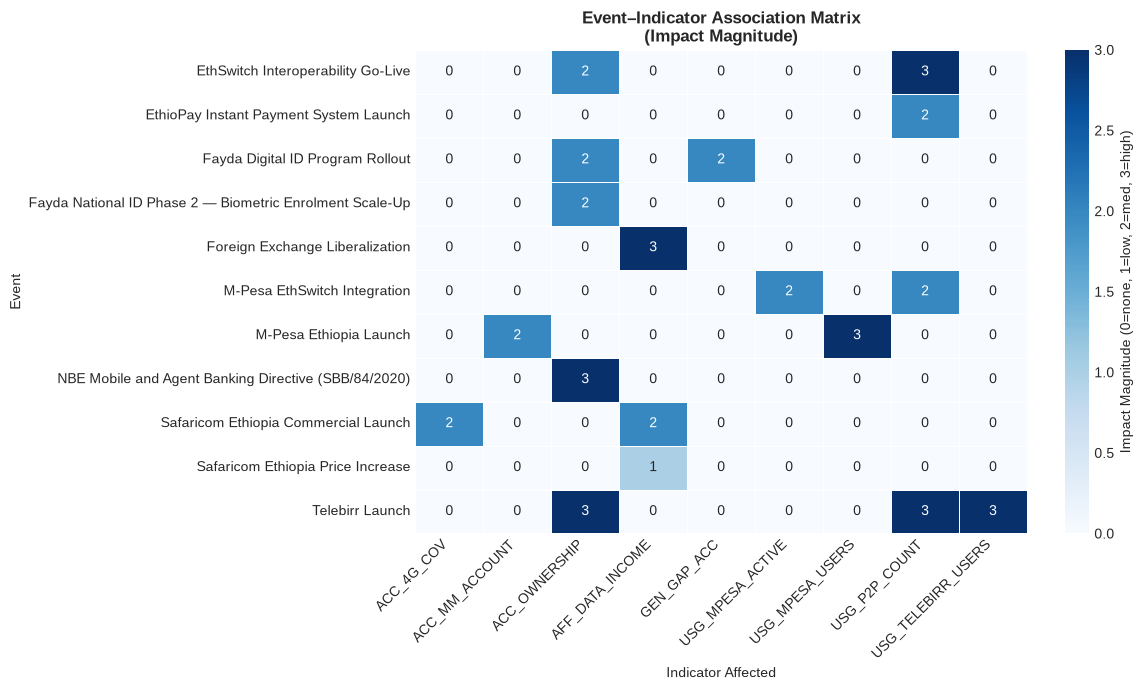

In [14]:
# Association heatmap: which events affect which indicators
pivot = imp_joined.pivot_table(index='indicator_event', columns='related_indicator',
                                values='impact_magnitude',
                                aggfunc=lambda x: ','.join(x.astype(str)))
mag_num = imp_joined.copy()
mag_num['mag_score'] = mag_num['impact_magnitude'].map({'high':3,'medium':2,'low':1,'negligible':0})
pivot_num = mag_num.pivot_table(index='indicator_event', columns='related_indicator',
                                 values='mag_score', aggfunc='max', fill_value=0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot_num, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Impact Magnitude (0=none, 1=low, 2=med, 3=high)'})
ax.set_title('Event–Indicator Association Matrix\n(Impact Magnitude)', fontsize=12, fontweight='bold')
ax.set_xlabel('Indicator Affected')
ax.set_ylabel('Event')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig9_association_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Key Insights Summary

---

### 📌 Insight 1: The 2021–2024 Stagnation Puzzle
Ethiopia added 65M+ mobile money accounts between 2021 and 2024, yet account ownership only grew +3pp
(46%→49%). The Findex measures **active use in the past 12 months**, not registration.
With a 66% activity rate, roughly 34% of registered accounts are dormant.
This means the headline mobile money growth is real but **hasn't translated into sustained active usage**
at the pace needed to move the Findex needle.

**Implication:** Policies should focus on activation and repeat use, not just registration drives.

---

### 📌 Insight 2: P2P Transactions Surpassed ATM Withdrawals (1.08x)
In October 2024, P2P digital transfers exceeded ATM cash withdrawals for the first time.
P2P transactions grew from 49.7M (Jul 2024) to 128.3M (Jul 2025) — a **2.6x jump in one year**.
This is the clearest signal of genuine behavioral change in Ethiopia's payment ecosystem.

**Implication:** Ethiopia has passed the digital payments tipping point. The focus can now shift
from adoption to deepening usage (merchant payments, bill pay, savings).

---

### 📌 Insight 3: Stubborn Gender Gap (18pp) Rooted in Mobile Phone Access
Despite Telebirr's massive user base, the account ownership gender gap remains 18pp (2024).
Female mobile money share is only 14%. The root cause is a **24pp mobile phone gender gap** —
women simply have less access to the device needed to use mobile money.

**Implication:** Device access programs and female-friendly agent networks are prerequisites
for closing the inclusion gender gap.

---

### 📌 Insight 4: Fayda Digital ID is Ethiopia's Biggest Upcoming Inclusion Lever
With 15M enrollments by May 2025 (target: 90M by 2028), Fayda reduces KYC friction for account opening.
India's Aadhaar evidence shows digital ID scaled inclusion by ~35pp over 5 years.
If Fayda reaches 60M by 2027, this could unlock an additional **5–8pp** in account ownership.

**Implication:** NBE should mandate Fayda-based e-KYC for all mobile money onboarding.

---

### 📌 Insight 5: NFIS-II 70% Target Is 21pp Away — Unreachable by 2025
At the current best-case pace of ~4pp/year, the 70% target requires until **2028** under an optimistic
scenario. The 2024 baseline of 49% leaves a 21pp gap with only months until the 2025 deadline.

**Implication:** NFIS-III should set evidence-based targets with quarterly supply-side monitoring
rather than waiting for the next Findex survey in 2027.

---

### 📌 Insight 6: Infrastructure Is the Binding Constraint for Rural Inclusion
4G coverage reached 71% of population (2025) but **electricity access is only ~45%**
and mobile internet penetration is ~28%. In rural Ethiopia (~80% of population),
the constraint isn't the mobile network — it's **power, device ownership, and literacy**.

**Implication:** Financial inclusion investments must be paired with rural electrification
and digital literacy programs to achieve meaningful impact beyond urban centers.

---

### 📌 Insight 7: The Registered vs Active Gap Overstates Telebirr's Impact
Telebirr has 54.8M registered users but an estimated 36.2M active users (66% rate).
At 130M population with ~60% adults, this implies ~46% coverage by active Telebirr users alone —
yet Findex reports only 9.45% have a mobile money account.
This **survey definition gap** (Findex asks about past-12-months active use of specific products)
explains most of the apparent contradiction between operator and Findex numbers.


## 13. Data Quality & Limitations

| Limitation | Impact | Mitigation |
|------------|--------|------------|
| Only 5 Findex points over 13 years | Very sparse time series for regression | Use event-augmented models, wide CIs |
| Registered vs active confusion | Overstates inclusion if using operator data | Always use Findex for headline indicator |
| Findex methodology change (2021+) | Mobile money added to account definition | Treat 2011–2017 and 2021–2024 as separate series |
| Gender data only from 2021 onward | Limited gender trend analysis | Added 2014/2017 from Findex microdata |
| No regional disaggregation | Can't identify which regions lag most | Supplement with NBE regional data in Task 3 |
| Supply-side data is annual | Misses intra-year dynamics | Use as context, not primary forecast input |


In [15]:
print("✅ Task 2 EDA Complete")
print(f"   Figures generated: 9 (saved to reports/figures/)")
print(f"   Insights documented: 7")
print(f"   Observations analysed: {len(obs)}")
print(f"   Events on timeline: {len(events)}")
print(f"   Impact links reviewed: {len(impact)}")


✅ Task 2 EDA Complete
   Figures generated: 9 (saved to reports/figures/)
   Insights documented: 7
   Observations analysed: 45
   Events on timeline: 15
   Impact links reviewed: 18
